# Notebook 7 - ModelNet40 Primitive-Like Subset Evaluation

This notebook evaluates the final mixed-trained XYZ-only PointNet++ model on an external ModelNet40 primitive-like subset.

The full 40-class ModelNet40 dataset is not evaluated directly because the trained model predicts only three primitive classes: box, cylinder and sphere. Therefore, selected ModelNet40 categories are mapped to the three project classes.

The final subset contains 9 selected categories and 486 test samples. The evaluation uses 10-vote test-time voting across 9 independently trained mixed checkpoints.

In [1]:
# Cell 1 - Mount Drive and Set Project Paths
from google.colab import drive
drive.mount("/content/gdrive", force_remount=True)

from pathlib import Path
import os, sys, zipfile, subprocess, shutil
import numpy as np
import pandas as pd

PROJECT_DIR = Path("/content/gdrive/MyDrive/PointNet_APS_Project_V2")

MODELNET_DIR = PROJECT_DIR / "data" / "modelnet40"
RESULTS_DIR = PROJECT_DIR / "results_final_xyz" / "modelnet40_results"
SRC_DIR = PROJECT_DIR / "src"

FIG_DIR = PROJECT_DIR / "figures_final_analysis" / "modelnet40_subset_voting"
TABLE_DIR = PROJECT_DIR / "final_analysis_tables" / "modelnet40_subset_voting"

MODELNET_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
SRC_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("Project exists:", PROJECT_DIR.exists())
print("Project path:", PROJECT_DIR)
print("ModelNet folder:", MODELNET_DIR)
print("Results folder:", RESULTS_DIR)
print("Figures folder:", FIG_DIR)
print("Tables folder:", TABLE_DIR)

Mounted at /content/gdrive
Project exists: True
Project path: /content/gdrive/MyDrive/PointNet_APS_Project_V2
ModelNet folder: /content/gdrive/MyDrive/PointNet_APS_Project_V2/data/modelnet40
Results folder: /content/gdrive/MyDrive/PointNet_APS_Project_V2/results_final_xyz/modelnet40_results
Figures folder: /content/gdrive/MyDrive/PointNet_APS_Project_V2/figures_final_analysis/modelnet40_subset_voting
Tables folder: /content/gdrive/MyDrive/PointNet_APS_Project_V2/final_analysis_tables/modelnet40_subset_voting


In [2]:
# Cell 2 - Check Trained Model Checkpoints
ckpt_dir = PROJECT_DIR / "models_final_xyz" / "mixed_trained_xyz"

print("Checkpoint folder:", ckpt_dir)
print("Checkpoint folder exists:", ckpt_dir.exists())

checkpoints = sorted(ckpt_dir.glob("*.pth"))

print("Checkpoints found:", len(checkpoints))

for p in checkpoints:
    print(p.name)

if len(checkpoints) != 9:
   raise RuntimeError(
    "Expected 9 mixed_trained_xyz checkpoints. "
    "Check the final AdamW training outputs."
)

Checkpoint folder: /content/gdrive/MyDrive/PointNet_APS_Project_V2/models_final_xyz/mixed_trained_xyz
Checkpoint folder exists: True
Checkpoints found: 9
mixed_trained_xyz_run_1_best.pth
mixed_trained_xyz_run_2_best.pth
mixed_trained_xyz_run_3_best.pth
mixed_trained_xyz_run_4_best.pth
mixed_trained_xyz_run_5_best.pth
mixed_trained_xyz_run_6_best.pth
mixed_trained_xyz_run_7_best.pth
mixed_trained_xyz_run_8_best.pth
mixed_trained_xyz_run_9_best.pth


In [3]:
# Cell 3 - Download and extract ModelNet40 HDF5 dataset
zip_path = MODELNET_DIR / "modelnet40_ply_hdf5_2048.zip"
extract_dir = MODELNET_DIR / "modelnet40_ply_hdf5_2048"

url = "https://huggingface.co/datasets/Msun/modelnet40/resolve/main/modelnet40_ply_hdf5_2048.zip"

if extract_dir.exists():
    print("Dataset already extracted at:", extract_dir)
else:
    if zip_path.exists() and zip_path.stat().st_size < 100 * 1024 * 1024:
        print("Removing incomplete zip:", zip_path)
        zip_path.unlink()

    if not zip_path.exists():
        print("Downloading ModelNet40 HDF5 point-cloud dataset...")

        cmd = [
            "wget",
            "-c",
            "--tries=5",
            "--timeout=120",
            "-O", str(zip_path),
            url
        ]

        result = subprocess.run(cmd)

        if result.returncode != 0:
            raise RuntimeError("Download failed. Try again or upload the zip manually.")

        print("Download completed.")
        print("Zip size MB:", round(zip_path.stat().st_size / (1024 * 1024), 2))

    print("Extracting...")

    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(MODELNET_DIR)

    print("Extraction completed.")

print("Dataset ready at:", extract_dir)

print("\nFiles:")
for p in sorted(extract_dir.glob("*")):
    print(p.name)

Dataset already extracted at: /content/gdrive/MyDrive/PointNet_APS_Project_V2/data/modelnet40/modelnet40_ply_hdf5_2048
Dataset ready at: /content/gdrive/MyDrive/PointNet_APS_Project_V2/data/modelnet40/modelnet40_ply_hdf5_2048

Files:
ply_data_test0.h5
ply_data_test1.h5
ply_data_test_0_id2file.json
ply_data_test_1_id2file.json
ply_data_train0.h5
ply_data_train1.h5
ply_data_train2.h5
ply_data_train3.h5
ply_data_train4.h5
ply_data_train_0_id2file.json
ply_data_train_1_id2file.json
ply_data_train_2_id2file.json
ply_data_train_3_id2file.json
ply_data_train_4_id2file.json
shape_names.txt
test_files.txt
train_files.txt


In [4]:
# Cell 4 - Load ModelNet40 Test Data
import h5py

shape_names_path = extract_dir / "shape_names.txt"

with open(shape_names_path, "r") as f:
    shape_names = [line.strip() for line in f.readlines()]

print("Number of ModelNet40 classes:", len(shape_names))
print(shape_names)

test_files_path = extract_dir / "test_files.txt"

with open(test_files_path, "r") as f:
    test_files = [line.strip().split("/")[-1] for line in f.readlines()]

print("\nTest files:")
print(test_files)

all_points = []
all_labels = []

for fname in test_files:
    h5_path = extract_dir / fname
    print("Loading:", h5_path.name)

    with h5py.File(h5_path, "r") as f:
        data = f["data"][:]       # [samples, 2048, 3]
        label = f["label"][:]     # [samples, 1]

    all_points.append(data)
    all_labels.append(label)

points = np.concatenate(all_points, axis=0)
labels = np.concatenate(all_labels, axis=0).reshape(-1)

modelnet_df = pd.DataFrame({
    "modelnet_label": labels,
    "modelnet_class": [shape_names[i] for i in labels]
})

print("Loaded ModelNet40 test points:", points.shape)
print("Loaded labels:", labels.shape)

display(modelnet_df["modelnet_class"].value_counts().sort_index())

Number of ModelNet40 classes: 40
['airplane', 'bathtub', 'bed', 'bench', 'bookshelf', 'bottle', 'bowl', 'car', 'chair', 'cone', 'cup', 'curtain', 'desk', 'door', 'dresser', 'flower_pot', 'glass_box', 'guitar', 'keyboard', 'lamp', 'laptop', 'mantel', 'monitor', 'night_stand', 'person', 'piano', 'plant', 'radio', 'range_hood', 'sink', 'sofa', 'stairs', 'stool', 'table', 'tent', 'toilet', 'tv_stand', 'vase', 'wardrobe', 'xbox']

Test files:
['ply_data_test0.h5', 'ply_data_test1.h5']
Loading: ply_data_test0.h5
Loading: ply_data_test1.h5
Loaded ModelNet40 test points: (2468, 2048, 3)
Loaded labels: (2468,)


,count
modelnet_class,
airplane,100
bathtub,50
bed,100
bench,20
bookshelf,100
bottle,100
bowl,20
car,100
chair,100


#Select Primitive-Like ModelNet40 Categories

The final ModelNet40 subset uses 9 selected categories:

- Box-like: `glass_box`, `xbox`, `wardrobe`, `night_stand`
- Cylinder-like: `bottle`, `cup`, `vase`, `flower_pot`
- Sphere-like proxy: `bowl`

Additional categories such as door, laptop, monitor, keyboard, radio, desk and bookshelf were tested separately, but they reduced the overall accuracy and are not included in the final subset.

In [5]:
# Cell 5 - Select Primitive-Like ModelNet40 Categories
# Final selected ModelNet40 primitive-like subset


MODELNET_TO_PRIMITIVE = {
    # box-like
    "glass_box": "box",
    "xbox": "box",
    "wardrobe": "box",
    "night_stand": "box",

    # cylinder-like
    "bottle": "cylinder",
    "cup": "cylinder",
    "vase": "cylinder",
    "flower_pot": "cylinder",

    # weak sphere-like proxy
    "bowl": "sphere"
}

PRIMITIVE_TO_IDX = {
    "box": 0,
    "cylinder": 1,
    "sphere": 2
}

IDX_TO_PRIMITIVE = {
    0: "box",
    1: "cylinder",
    2: "sphere"
}

selected_indices = []
rows = []

for i, cls in enumerate(modelnet_df["modelnet_class"]):
    if cls in MODELNET_TO_PRIMITIVE:
        primitive = MODELNET_TO_PRIMITIVE[cls]

        selected_indices.append(i)

        rows.append({
            "sample_index": i,
            "modelnet_class": cls,
            "primitive_label": primitive,
            "primitive_idx": PRIMITIVE_TO_IDX[primitive]
        })

subset_df = pd.DataFrame(rows)
subset_points = points[selected_indices]

print("Selected ModelNet40 primitive-like subset:", subset_points.shape)

print("\nPrimitive class counts:")
display(subset_df["primitive_label"].value_counts())

print("\nOriginal ModelNet40 category counts:")
display(subset_df["modelnet_class"].value_counts().sort_index())

subset_manifest_path = RESULTS_DIR / "modelnet40_primitive_subset_manifest.csv"
subset_df.to_csv(subset_manifest_path, index=False)

print("Saved subset manifest:", subset_manifest_path)

Selected ModelNet40 primitive-like subset: (486, 2048, 3)

Primitive class counts:


,count
primitive_label,
cylinder,240
box,226
sphere,20



Original ModelNet40 category counts:


,count
modelnet_class,
bottle,100
bowl,20
cup,20
flower_pot,20
glass_box,100
night_stand,86
vase,100
wardrobe,20
xbox,20


Saved subset manifest: /content/gdrive/MyDrive/PointNet_APS_Project_V2/results_final_xyz/modelnet40_results/modelnet40_primitive_subset_manifest.csv


In [6]:
# Cell 6 - Normalise and Sample Point Clouds
from tqdm import tqdm

N_POINTS = 1000

rng = np.random.default_rng(42)

def normalise_xyz_bbox_style(xyz):
    xyz = xyz.astype(np.float32)

    # Centre around origin
    xyz = xyz - xyz.mean(axis=0, keepdims=True)

    # Scale using bounding-box diagonal
    mins = xyz.min(axis=0)
    maxs = xyz.max(axis=0)
    diagonal = np.linalg.norm(maxs - mins)

    if diagonal > 0:
        xyz = xyz / diagonal

    return xyz.astype(np.float32)

def sample_points(xyz, n_points=1000):
    if xyz.shape[0] >= n_points:
        idx = rng.choice(xyz.shape[0], n_points, replace=False)
    else:
        idx = rng.choice(xyz.shape[0], n_points, replace=True)

    return xyz[idx]

processed_points = []

for pc in tqdm(subset_points, desc="Normalising and sampling"):
    pc = normalise_xyz_bbox_style(pc)
    pc = sample_points(pc, N_POINTS)
    processed_points.append(pc)

processed_points = np.stack(processed_points, axis=0)

print("Processed ModelNet40 subset shape:", processed_points.shape)

Normalising and sampling: 100%|██████████| 486/486 [00:00<00:00, 3464.28it/s]

Processed ModelNet40 subset shape: (486, 1000, 3)


In [7]:
# Cell 7 - Load PointNet++ Model Code
import torch
import torch.nn as nn
import torch.nn.functional as F

utility_path = SRC_DIR / "pointnetpp_aps_utils.py"

if not utility_path.exists():
    raise FileNotFoundError(
    f"Utility file missing: {utility_path}\n"
    "Restore pointnetpp_aps_utils.py from the source-code folder."
)

sys.path.insert(0, str(SRC_DIR))

from pointnetpp_aps_utils import PointNetPPClassifier

print("Imported PointNetPPClassifier successfully.")

Imported PointNetPPClassifier successfully.


In [ ]:
# Cell 8 - Create Dataset Class and Checkpoint Loader
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

class ModelNetPrimitiveDataset(Dataset):
    def __init__(self, points_array, dataframe):
        self.points = points_array
        self.df = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        xyz = self.points[idx]                         # [1000, 3]
        xyz = torch.tensor(xyz.T, dtype=torch.float32) # [3, 1000]

        label = int(self.df.loc[idx, "primitive_idx"])

        return {
            "points": xyz,
            "label": torch.tensor(label, dtype=torch.long),
            "modelnet_class": self.df.loc[idx, "modelnet_class"],
            "primitive_label": self.df.loc[idx, "primitive_label"],
            "sample_index": int(self.df.loc[idx, "sample_index"])
        }

def load_checkpoint(model, ckpt_path):
    ckpt = torch.load(ckpt_path, map_location=device)

    if isinstance(ckpt, dict) and "model_state_dict" in ckpt:
        state = ckpt["model_state_dict"]
    elif isinstance(ckpt, dict) and "state_dict" in ckpt:
        state = ckpt["state_dict"]
    else:
        state = ckpt

    clean_state = {}

    for k, v in state.items():
        clean_state[k.replace("module.", "")] = v

    model.load_state_dict(clean_state, strict=True)

    return model

Device: cuda


#Prepare 10 Test-Time Votes

Each ModelNet40 point cloud is resampled 10 times. The model predicts each sampled version, and the final class is selected by averaging the predicted probabilities across all votes.

This improves evaluation stability without changing the trained model.

In [ ]:
# Cell 9 - Prepare 10 Test-Time Votes
# Test-time voting setup
# Each point cloud is resampled 10 times.
# The model probabilities are averaged across votes.

VOTES = 10
N_POINTS = 1000

rng = np.random.default_rng(123)

def make_voted_points(original_points, n_points=1000, votes=10):
    voted = []

    for v in range(votes):
        processed = []

        for pc in original_points:
            pc_norm = normalise_xyz_bbox_style(pc)
            pc_sampled = sample_points(pc_norm, n_points)
            processed.append(pc_sampled)

        voted.append(np.stack(processed, axis=0))

    return voted

voted_points_list = make_voted_points(
    subset_points,
    n_points=N_POINTS,
    votes=VOTES
)

print("Votes prepared:", len(voted_points_list))
print("Each vote shape:", voted_points_list[0].shape)

Votes prepared: 10
Each vote shape: (486, 1000, 3)


In [ ]:
# Cell 10 - Define Voting Evaluation Function
class ModelNetPrimitiveDatasetVote(Dataset):
    def __init__(self, points_array, dataframe):
        self.points = points_array
        self.df = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        xyz = self.points[idx]
        xyz = torch.tensor(xyz.T, dtype=torch.float32)

        label = int(self.df.loc[idx, "primitive_idx"])

        return {
            "points": xyz,
            "label": torch.tensor(label, dtype=torch.long),
            "modelnet_class": self.df.loc[idx, "modelnet_class"],
            "primitive_label": self.df.loc[idx, "primitive_label"],
            "sample_index": int(self.df.loc[idx, "sample_index"])
        }

def evaluate_checkpoint_with_voting(ckpt_path, train_condition, voted_points_list):
    model = PointNetPPClassifier(num_classes=3, normal_channel=False).to(device)
    model = load_checkpoint(model, ckpt_path)
    model.eval()

    all_vote_probs = []

    with torch.no_grad():
        for vote_points in voted_points_list:
            vote_dataset = ModelNetPrimitiveDatasetVote(vote_points, subset_df)
            vote_loader = DataLoader(vote_dataset, batch_size=16, shuffle=False)

            vote_probs = []

            for batch in vote_loader:
                x = batch["points"].to(device)

                logits = model(x)

                if isinstance(logits, tuple):
                    logits = logits[0]

                probs = torch.softmax(logits, dim=1)

                vote_probs.append(probs.cpu().numpy())

            vote_probs = np.concatenate(vote_probs, axis=0)
            all_vote_probs.append(vote_probs)

    mean_probs = np.mean(np.stack(all_vote_probs, axis=0), axis=0)

    y_true = subset_df["primitive_idx"].values
    y_pred = mean_probs.argmax(axis=1)
    confidence = mean_probs.max(axis=1)

    accuracy = (y_true == y_pred).mean() * 100

    rows = []

    for i in range(len(subset_df)):
        rows.append({
            "train_condition": train_condition,
            "checkpoint": Path(ckpt_path).name,
            "sample_index": int(subset_df.loc[i, "sample_index"]),
            "modelnet_class": subset_df.loc[i, "modelnet_class"],
            "true_primitive": IDX_TO_PRIMITIVE[int(y_true[i])],
            "pred_primitive": IDX_TO_PRIMITIVE[int(y_pred[i])],
            "correct": bool(y_true[i] == y_pred[i]),
            "confidence": float(confidence[i]),
            "votes": len(voted_points_list)
        })

    summary = {
        "train_condition": train_condition,
        "checkpoint": Path(ckpt_path).name,
        "accuracy_percent": accuracy,
        "n_samples": len(y_true),
        "mean_confidence": float(np.mean(confidence)),
        "votes": len(voted_points_list)
    }

    return summary, rows

In [ ]:
# Cell 11 - Run Voting Evaluation on Mixed-Trained Models
condition = "mixed_trained_xyz"

ckpt_dir = PROJECT_DIR / "models_final_xyz" / condition
checkpoints = sorted(ckpt_dir.glob("*.pth"))

print("Condition:", condition)
print("Checkpoints found:", len(checkpoints))

voting_summary_rows = []
voting_prediction_rows = []

for ckpt_path in checkpoints:
    print("Evaluating with voting:", ckpt_path.name)

    summary, rows = evaluate_checkpoint_with_voting(
        ckpt_path,
        condition,
        voted_points_list
    )

    voting_summary_rows.append(summary)
    voting_prediction_rows.extend(rows)

voting_summary_df = pd.DataFrame(voting_summary_rows)
voting_pred_df = pd.DataFrame(voting_prediction_rows)

voting_summary_path = RESULTS_DIR / "modelnet40_subset_mixed_voting_summary.csv"
voting_pred_path = RESULTS_DIR / "modelnet40_subset_mixed_voting_predictions.csv"

voting_summary_df.to_csv(voting_summary_path, index=False)
voting_pred_df.to_csv(voting_pred_path, index=False)

print("\nSaved:")
print(voting_summary_path)
print(voting_pred_path)

display(voting_summary_df)

print("Mean voting accuracy:", voting_summary_df["accuracy_percent"].mean())
print("Median voting accuracy:", voting_summary_df["accuracy_percent"].median())
print("Best voting accuracy:", voting_summary_df["accuracy_percent"].max())

Condition: mixed_trained_xyz
Checkpoints found: 9
Evaluating with voting: mixed_trained_xyz_run_1_best.pth
Evaluating with voting: mixed_trained_xyz_run_2_best.pth
Evaluating with voting: mixed_trained_xyz_run_3_best.pth
Evaluating with voting: mixed_trained_xyz_run_4_best.pth
Evaluating with voting: mixed_trained_xyz_run_5_best.pth
Evaluating with voting: mixed_trained_xyz_run_6_best.pth
Evaluating with voting: mixed_trained_xyz_run_7_best.pth
Evaluating with voting: mixed_trained_xyz_run_8_best.pth
Evaluating with voting: mixed_trained_xyz_run_9_best.pth

Saved:
/content/gdrive/MyDrive/PointNet_APS_Project_V2/results_final_xyz/modelnet40_results/modelnet40_subset_mixed_voting_summary.csv
/content/gdrive/MyDrive/PointNet_APS_Project_V2/results_final_xyz/modelnet40_results/modelnet40_subset_mixed_voting_predictions.csv


,train_condition,checkpoint,accuracy_percent,n_samples,mean_confidence,votes
0,mixed_trained_xyz,mixed_trained_xyz_run_1_best.pth,80.246914,486,0.879959,10
1,mixed_trained_xyz,mixed_trained_xyz_run_2_best.pth,84.979424,486,0.883217,10
2,mixed_trained_xyz,mixed_trained_xyz_run_3_best.pth,70.781893,486,0.870067,10
3,mixed_trained_xyz,mixed_trained_xyz_run_4_best.pth,82.304527,486,0.873368,10
4,mixed_trained_xyz,mixed_trained_xyz_run_5_best.pth,80.864198,486,0.869208,10
5,mixed_trained_xyz,mixed_trained_xyz_run_6_best.pth,83.950617,486,0.895320,10
6,mixed_trained_xyz,mixed_trained_xyz_run_7_best.pth,78.600823,486,0.888324,10
7,mixed_trained_xyz,mixed_trained_xyz_run_8_best.pth,84.567901,486,0.856781,10
8,mixed_trained_xyz,mixed_trained_xyz_run_9_best.pth,82.716049,486,0.904341,10


Mean voting accuracy: 81.00137174211248
Median voting accuracy: 82.3045267489712
Best voting accuracy: 84.97942386831275


# Final Voting Accuracy Summary

This cell reports the final ModelNet40 voting result for the mixed-trained XYZ-only PointNet++ model.

The main values to report are:

- Mean accuracy
- Median accuracy
- Best checkpoint accuracy

In [ ]:
# Cell 12 - Final Voting Accuracy Summary
acc = voting_summary_df["accuracy_percent"].dropna().values

final_voting_summary = pd.DataFrame([{
    "evaluation": "ModelNet40 primitive-like subset with 10-vote test-time voting",
    "train_condition": "mixed_trained_xyz",
    "n_checkpoints": len(acc),
    "n_samples": int(voting_summary_df["n_samples"].iloc[0]),
    "votes": int(voting_summary_df["votes"].iloc[0]),
    "mean_accuracy_percent": np.mean(acc),
    "std_accuracy_percent": np.std(acc, ddof=1),
    "min_accuracy_percent": np.min(acc),
    "q1_accuracy_percent": np.percentile(acc, 25),
    "median_accuracy_percent": np.median(acc),
    "q3_accuracy_percent": np.percentile(acc, 75),
    "max_accuracy_percent": np.max(acc),
    "mean_confidence": voting_summary_df["mean_confidence"].mean()
}])

display(final_voting_summary)

summary_out = TABLE_DIR / "modelnet40_voting_final_summary.csv"
final_voting_summary.to_csv(summary_out, index=False)

print("Saved:", summary_out)

,evaluation,train_condition,n_checkpoints,n_samples,votes,mean_accuracy_percent,std_accuracy_percent,min_accuracy_percent,q1_accuracy_percent,median_accuracy_percent,q3_accuracy_percent,max_accuracy_percent,mean_confidence
0,ModelNet40 primitive-like subset with 10-vote ...,mixed_trained_xyz,9,486,10,81.001372,4.368493,70.781893,80.246914,82.304527,83.950617,84.979424,0.880065


Saved: /content/gdrive/MyDrive/PointNet_APS_Project_V2/final_analysis_tables/modelnet40_subset_voting/modelnet40_voting_final_summary.csv


In [ ]:
# Cell 13 - Five-Number Summary of Voting Accuracy
five_number_summary = pd.DataFrame([{
    "train_condition": "mixed_trained_xyz",
    "evaluation": "10-vote test-time voting",
    "n_checkpoints": len(acc),
    "Minimum": np.min(acc),
    "Q1": np.percentile(acc, 25),
    "Median": np.median(acc),
    "Q3": np.percentile(acc, 75),
    "Maximum": np.max(acc),
    "Mean": np.mean(acc),
    "Std": np.std(acc, ddof=1)
}])

display(five_number_summary)

five_out = TABLE_DIR / "modelnet40_voting_five_number_summary.csv"
five_number_summary.to_csv(five_out, index=False)

print("Saved:", five_out)

,train_condition,evaluation,n_checkpoints,Minimum,Q1,Median,Q3,Maximum,Mean,Std
0,mixed_trained_xyz,10-vote test-time voting,9,70.781893,80.246914,82.304527,83.950617,84.979424,81.001372,4.368493


Saved: /content/gdrive/MyDrive/PointNet_APS_Project_V2/final_analysis_tables/modelnet40_subset_voting/modelnet40_voting_five_number_summary.csv


,run_id,checkpoint,accuracy_percent,n_samples,mean_confidence,votes
0,1,mixed_trained_xyz_run_1_best.pth,80.246914,486,0.879959,10
1,2,mixed_trained_xyz_run_2_best.pth,84.979424,486,0.883217,10
2,3,mixed_trained_xyz_run_3_best.pth,70.781893,486,0.870067,10
3,4,mixed_trained_xyz_run_4_best.pth,82.304527,486,0.873368,10
4,5,mixed_trained_xyz_run_5_best.pth,80.864198,486,0.869208,10
5,6,mixed_trained_xyz_run_6_best.pth,83.950617,486,0.895320,10
6,7,mixed_trained_xyz_run_7_best.pth,78.600823,486,0.888324,10
7,8,mixed_trained_xyz_run_8_best.pth,84.567901,486,0.856781,10
8,9,mixed_trained_xyz_run_9_best.pth,82.716049,486,0.904341,10


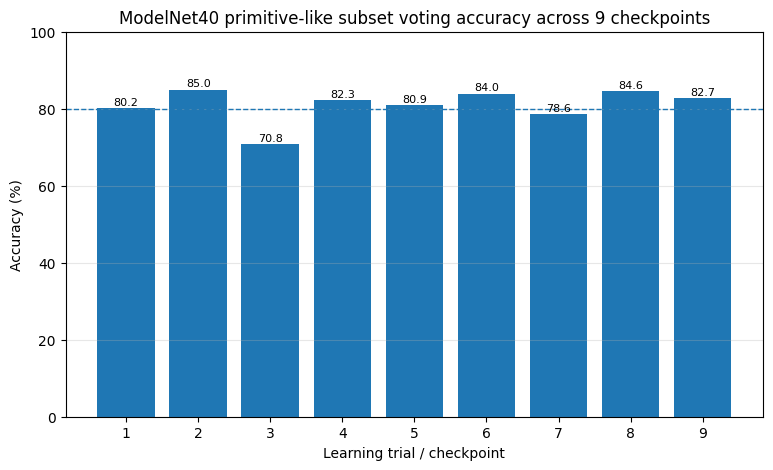

Saved table: /content/gdrive/MyDrive/PointNet_APS_Project_V2/final_analysis_tables/modelnet40_subset_voting/modelnet40_voting_runwise_results.csv
Saved figure: /content/gdrive/MyDrive/PointNet_APS_Project_V2/figures_final_analysis/modelnet40_subset_voting/modelnet40_voting_runwise_accuracy_bar.png


In [ ]:
# Cell 14 - Run-Wise Voting Accuracy Plot
import matplotlib.pyplot as plt

runwise_df = voting_summary_df.copy()

runwise_df["run_id"] = (
    runwise_df["checkpoint"]
    .str.extract(r"run_(\d+)")
    .astype(int)
)

runwise_df = runwise_df.sort_values("run_id").reset_index(drop=True)

display(runwise_df[[
    "run_id",
    "checkpoint",
    "accuracy_percent",
    "n_samples",
    "mean_confidence",
    "votes"
]])

runwise_out = TABLE_DIR / "modelnet40_voting_runwise_results.csv"
runwise_df.to_csv(runwise_out, index=False)

plt.figure(figsize=(9, 5))
plt.bar(runwise_df["run_id"].astype(str), runwise_df["accuracy_percent"])
plt.axhline(80, linestyle="--", linewidth=1)

plt.xlabel("Learning trial / checkpoint")
plt.ylabel("Accuracy (%)")
plt.title("ModelNet40 primitive-like subset voting accuracy across 9 checkpoints")
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)

for i, v in enumerate(runwise_df["accuracy_percent"]):
    plt.text(i, v + 0.7, f"{v:.1f}", ha="center", fontsize=8)

bar_path = FIG_DIR / "modelnet40_voting_runwise_accuracy_bar.png"
plt.savefig(bar_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved table:", runwise_out)
print("Saved figure:", bar_path)

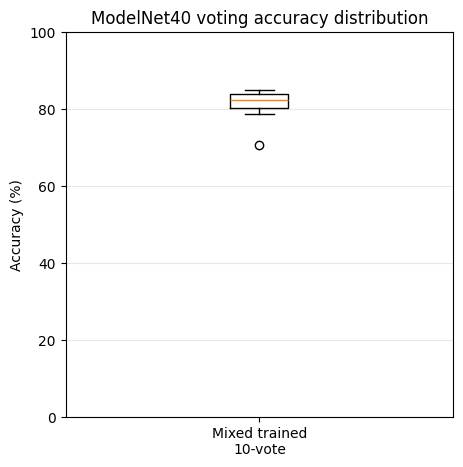

Saved: /content/gdrive/MyDrive/PointNet_APS_Project_V2/figures_final_analysis/modelnet40_subset_voting/modelnet40_voting_accuracy_boxplot.png


In [ ]:
# Cell 15 - Voting Accuracy Box Plot
plt.figure(figsize=(5, 5))

plt.boxplot(
    [voting_summary_df["accuracy_percent"].dropna()],
    tick_labels=["Mixed trained\n10-vote"]
)

plt.ylabel("Accuracy (%)")
plt.title("ModelNet40 voting accuracy distribution")
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)

box_path = FIG_DIR / "modelnet40_voting_accuracy_boxplot.png"
plt.savefig(box_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", box_path)

Best voting checkpoint: mixed_trained_xyz_run_2_best.pth
Best voting accuracy: 84.97942386831275


,Pred box,Pred cylinder,Pred sphere
True box,218,8,0
True cylinder,45,195,0
True sphere,0,20,0


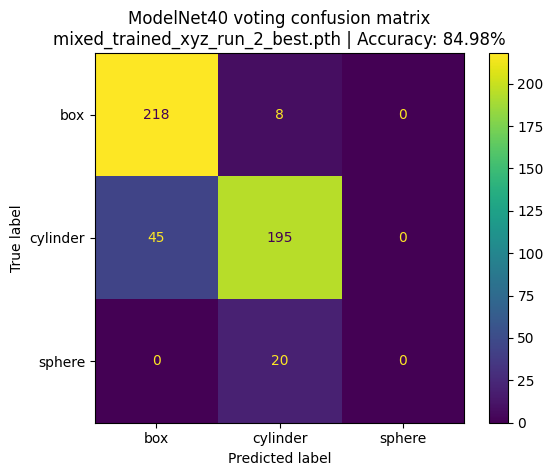

Saved: /content/gdrive/MyDrive/PointNet_APS_Project_V2/final_analysis_tables/modelnet40_subset_voting/modelnet40_voting_best_checkpoint_confusion_matrix.csv
Saved: /content/gdrive/MyDrive/PointNet_APS_Project_V2/figures_final_analysis/modelnet40_subset_voting/modelnet40_voting_best_checkpoint_confusion_matrix.png
              precision    recall  f1-score   support

         box       0.83      0.96      0.89       226
    cylinder       0.87      0.81      0.84       240
      sphere       0.00      0.00      0.00        20

    accuracy                           0.85       486
   macro avg       0.57      0.59      0.58       486
weighted avg       0.82      0.85      0.83       486



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Cell 16 - Best Checkpoint Confusion Matrix
best_row = voting_summary_df.sort_values("accuracy_percent", ascending=False).iloc[0]

best_checkpoint = best_row["checkpoint"]
best_accuracy = best_row["accuracy_percent"]

print("Best voting checkpoint:", best_checkpoint)
print("Best voting accuracy:", best_accuracy)

best_pred_df = voting_pred_df[voting_pred_df["checkpoint"] == best_checkpoint].copy()

labels_order = ["box", "cylinder", "sphere"]

cm = confusion_matrix(
    best_pred_df["true_primitive"],
    best_pred_df["pred_primitive"],
    labels=labels_order
)

cm_df = pd.DataFrame(
    cm,
    index=[f"True {x}" for x in labels_order],
    columns=[f"Pred {x}" for x in labels_order]
)

display(cm_df)

cm_out = TABLE_DIR / "modelnet40_voting_best_checkpoint_confusion_matrix.csv"
cm_df.to_csv(cm_out)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_order)
disp.plot(values_format="d")

plt.title(
    f"ModelNet40 voting confusion matrix\n"
    f"{best_checkpoint} | Accuracy: {best_accuracy:.2f}%"
)

cm_fig = FIG_DIR / "modelnet40_voting_best_checkpoint_confusion_matrix.png"
plt.savefig(cm_fig, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", cm_out)
print("Saved:", cm_fig)

print(classification_report(
    best_pred_df["true_primitive"],
    best_pred_df["pred_primitive"],
    labels=labels_order
))


,Pred box,Pred cylinder,Pred sphere
True box,217.111111,8.888889,0.0
True cylinder,63.444444,176.555556,0.0
True sphere,1.000000,19.000000,0.0


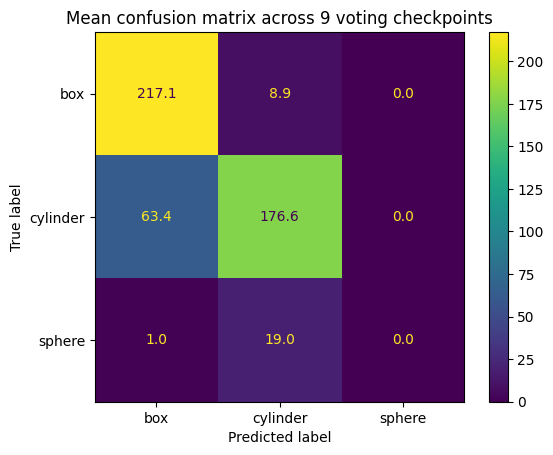

Saved: /content/gdrive/MyDrive/PointNet_APS_Project_V2/final_analysis_tables/modelnet40_subset_voting/modelnet40_voting_mean_confusion_matrix_across_9_checkpoints.csv
Saved: /content/gdrive/MyDrive/PointNet_APS_Project_V2/figures_final_analysis/modelnet40_subset_voting/modelnet40_voting_mean_confusion_matrix.png


In [ ]:
# Cell 17 - Mean Confusion Matrix Across 9 Runs
cms = []

for ckpt, grp in voting_pred_df.groupby("checkpoint"):
    cm_i = confusion_matrix(
        grp["true_primitive"],
        grp["pred_primitive"],
        labels=labels_order
    )

    cms.append(cm_i)

mean_cm = np.mean(np.stack(cms, axis=0), axis=0)

mean_cm_df = pd.DataFrame(
    mean_cm,
    index=[f"True {x}" for x in labels_order],
    columns=[f"Pred {x}" for x in labels_order]
)

display(mean_cm_df)

mean_cm_out = TABLE_DIR / "modelnet40_voting_mean_confusion_matrix_across_9_checkpoints.csv"
mean_cm_df.to_csv(mean_cm_out)

disp = ConfusionMatrixDisplay(confusion_matrix=mean_cm, display_labels=labels_order)
disp.plot(values_format=".1f")

plt.title("Mean confusion matrix across 9 voting checkpoints")

mean_cm_fig = FIG_DIR / "modelnet40_voting_mean_confusion_matrix.png"
plt.savefig(mean_cm_fig, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", mean_cm_out)
print("Saved:", mean_cm_fig)

,true_primitive,mean_accuracy_percent,std_accuracy_percent,min_accuracy_percent,median_accuracy_percent,max_accuracy_percent,mean_confidence
0,box,96.066863,3.314485,88.495575,97.345133,98.672566,0.926403
1,cylinder,73.564815,9.606203,53.333333,75.416667,83.333333,0.832572
2,sphere,0.000000,0.000000,0.000000,0.000000,0.000000,0.926354


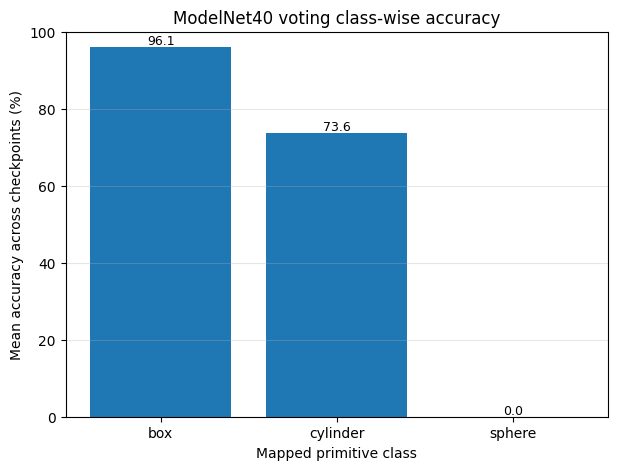

Saved: /content/gdrive/MyDrive/PointNet_APS_Project_V2/final_analysis_tables/modelnet40_subset_voting/modelnet40_voting_classwise_accuracy.csv
Saved: /content/gdrive/MyDrive/PointNet_APS_Project_V2/figures_final_analysis/modelnet40_subset_voting/modelnet40_voting_classwise_accuracy.png


In [ ]:
# Cell 18 - Class-Wise Accuracy
classwise_acc = (
    voting_pred_df
    .groupby(["checkpoint", "true_primitive"])
    .agg(
        n_samples=("correct", "count"),
        accuracy_percent=("correct", lambda x: x.mean() * 100),
        mean_confidence=("confidence", "mean")
    )
    .reset_index()
)

classwise_summary = (
    classwise_acc
    .groupby("true_primitive")
    .agg(
        mean_accuracy_percent=("accuracy_percent", "mean"),
        std_accuracy_percent=("accuracy_percent", "std"),
        min_accuracy_percent=("accuracy_percent", "min"),
        median_accuracy_percent=("accuracy_percent", "median"),
        max_accuracy_percent=("accuracy_percent", "max"),
        mean_confidence=("mean_confidence", "mean")
    )
    .reset_index()
    .sort_values("mean_accuracy_percent", ascending=False)
)

display(classwise_summary)

classwise_out = TABLE_DIR / "modelnet40_voting_classwise_accuracy.csv"
classwise_summary.to_csv(classwise_out, index=False)

plt.figure(figsize=(7, 5))
plt.bar(classwise_summary["true_primitive"], classwise_summary["mean_accuracy_percent"])

plt.ylabel("Mean accuracy across checkpoints (%)")
plt.xlabel("Mapped primitive class")
plt.title("ModelNet40 voting class-wise accuracy")
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)

for i, v in enumerate(classwise_summary["mean_accuracy_percent"]):
    plt.text(i, v + 0.7, f"{v:.1f}", ha="center", fontsize=9)

classwise_fig = FIG_DIR / "modelnet40_voting_classwise_accuracy.png"
plt.savefig(classwise_fig, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", classwise_out)
print("Saved:", classwise_fig)

,modelnet_class,true_primitive,n_checkpoints,samples_per_checkpoint,mean_accuracy_percent,std_accuracy_percent,min_accuracy_percent,median_accuracy_percent,max_accuracy_percent,mean_confidence
4,glass_box,box,9,100.0,98.888889,0.781736,97.000000,99.000000,100.000000,0.944765
7,wardrobe,box,9,20.0,96.666667,4.330127,90.000000,100.000000,100.000000,0.909495
8,xbox,box,9,20.0,95.555556,3.004626,90.000000,95.000000,100.000000,0.910749
5,night_stand,box,9,86.0,92.764858,7.091540,75.581395,95.348837,98.837209,0.912625
0,bottle,cylinder,9,100.0,76.111111,15.308857,44.000000,79.000000,94.000000,0.798494
6,vase,cylinder,9,100.0,74.888889,5.967505,62.000000,75.000000,82.000000,0.869490
3,flower_pot,cylinder,9,20.0,66.111111,7.817360,55.000000,65.000000,80.000000,0.824004
2,cup,cylinder,9,20.0,61.666667,10.606602,45.000000,60.000000,85.000000,0.826943
1,bowl,sphere,9,20.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.926354


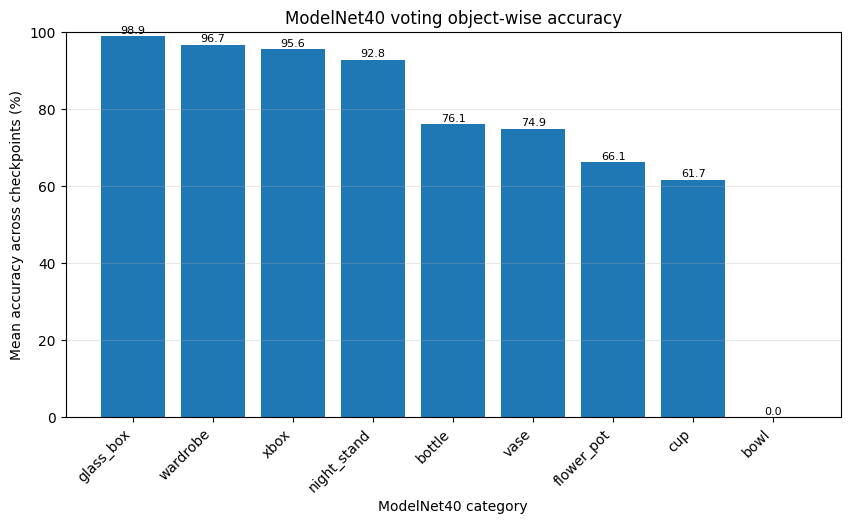

Saved: /content/gdrive/MyDrive/PointNet_APS_Project_V2/final_analysis_tables/modelnet40_subset_voting/modelnet40_voting_categorywise_accuracy.csv
Saved: /content/gdrive/MyDrive/PointNet_APS_Project_V2/figures_final_analysis/modelnet40_subset_voting/modelnet40_voting_categorywise_accuracy.png


In [ ]:
# Cell 19 — Object-Wise Accuracy
category_acc = (
    voting_pred_df
    .groupby(["checkpoint", "modelnet_class", "true_primitive"])
    .agg(
        n_predictions=("correct", "count"),
        accuracy_percent=("correct", lambda x: x.mean() * 100),
        mean_confidence=("confidence", "mean")
    )
    .reset_index()
)

category_summary = (
    category_acc
    .groupby(["modelnet_class", "true_primitive"])
    .agg(
        n_checkpoints=("checkpoint", "count"),
        samples_per_checkpoint=("n_predictions", "mean"),
        mean_accuracy_percent=("accuracy_percent", "mean"),
        std_accuracy_percent=("accuracy_percent", "std"),
        min_accuracy_percent=("accuracy_percent", "min"),
        median_accuracy_percent=("accuracy_percent", "median"),
        max_accuracy_percent=("accuracy_percent", "max"),
        mean_confidence=("mean_confidence", "mean")
    )
    .reset_index()
    .sort_values("mean_accuracy_percent", ascending=False)
)

display(category_summary)

category_out = TABLE_DIR / "modelnet40_voting_categorywise_accuracy.csv"
category_summary.to_csv(category_out, index=False)

plt.figure(figsize=(10, 5))
plt.bar(category_summary["modelnet_class"], category_summary["mean_accuracy_percent"])

plt.xticks(rotation=45, ha="right")
plt.ylabel("Mean accuracy across checkpoints (%)")
plt.xlabel("ModelNet40 category")
plt.title("ModelNet40 voting object-wise accuracy")
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)

for i, v in enumerate(category_summary["mean_accuracy_percent"]):
    plt.text(i, v + 0.7, f"{v:.1f}", ha="center", fontsize=8)

category_fig = FIG_DIR / "modelnet40_voting_categorywise_accuracy.png"
plt.savefig(category_fig, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", category_out)
print("Saved:", category_fig)

##  Bowl Prediction Analysis

ModelNet40 does not contain a true sphere or ball category. Therefore, `bowl` is used only as a weak sphere-like proxy.

This cell checks how the model predicts bowl samples. Poor bowl accuracy should be interpreted as a dataset-mapping limitation, not as direct failure on true spherical objects.

In [ ]:
# Cell 20 - Bowl Prediction Analysis
bowl_rows = voting_pred_df[voting_pred_df["modelnet_class"] == "bowl"].copy()

print("Total bowl predictions:", len(bowl_rows))
print("Expected: 20 bowl samples × 9 checkpoints = 180 predictions")

print("\nPredicted classes for bowl:")
display(bowl_rows["pred_primitive"].value_counts())

print("\nBowl prediction summary:")
bowl_summary = (
    bowl_rows
    .groupby(["true_primitive", "pred_primitive"])
    .agg(
        count=("correct", "count"),
        mean_confidence=("confidence", "mean")
    )
    .reset_index()
)

display(bowl_summary)

bowl_out = TABLE_DIR / "modelnet40_bowl_prediction_distribution.csv"
bowl_summary.to_csv(bowl_out, index=False)

print("Saved:", bowl_out)

Total bowl predictions: 180
Expected: 20 bowl samples × 9 checkpoints = 180 predictions

Predicted classes for bowl:


,count
pred_primitive,
cylinder,171
box,9



Bowl prediction summary:


,true_primitive,pred_primitive,count,mean_confidence
0,sphere,box,9,0.722478
1,sphere,cylinder,171,0.937084


Saved: /content/gdrive/MyDrive/PointNet_APS_Project_V2/final_analysis_tables/modelnet40_subset_voting/modelnet40_bowl_prediction_distribution.csv


In [ ]:
# Cell 21 - Prediction Distribution by Object
prediction_distribution = (
    voting_pred_df
    .groupby(["modelnet_class", "true_primitive", "pred_primitive"])
    .agg(
        count=("correct", "count"),
        mean_confidence=("confidence", "mean")
    )
    .reset_index()
)

prediction_distribution["percentage"] = (
    prediction_distribution
    .groupby("modelnet_class")["count"]
    .transform(lambda x: x / x.sum() * 100)
)

prediction_distribution = prediction_distribution.sort_values(
    ["modelnet_class", "percentage"],
    ascending=[True, False]
)

display(prediction_distribution)

pred_dist_out = TABLE_DIR / "modelnet40_prediction_distribution_by_object.csv"
prediction_distribution.to_csv(pred_dist_out, index=False)

print("Saved:", pred_dist_out)

,modelnet_class,true_primitive,pred_primitive,count,mean_confidence,percentage
1,bottle,cylinder,cylinder,685,0.817505,76.111111
0,bottle,cylinder,box,215,0.737925,23.888889
3,bowl,sphere,cylinder,171,0.937084,95.000000
2,bowl,sphere,box,9,0.722478,5.000000
5,cup,cylinder,cylinder,111,0.853561,61.666667
4,cup,cylinder,box,69,0.784122,38.333333
7,flower_pot,cylinder,cylinder,119,0.866651,66.111111
6,flower_pot,cylinder,box,61,0.740807,33.888889
8,glass_box,box,box,890,0.947267,98.888889
9,glass_box,box,cylinder,10,0.722048,1.111111


Saved: /content/gdrive/MyDrive/PointNet_APS_Project_V2/final_analysis_tables/modelnet40_subset_voting/modelnet40_prediction_distribution_by_object.csv


In [ ]:
# Cell 22 - Prepare Point Cloud Visualisation Data
# Use vote 1 point clouds for visualisation.
# These are normalised and sampled to 1000 points.

if "voted_points_list" in globals():
    points_for_vis = voted_points_list[0]
    print("Using voted_points_list[0] for visualisation:", points_for_vis.shape)
elif "processed_points" in globals():
    points_for_vis = processed_points
    print("Using processed_points for visualisation:", points_for_vis.shape)
else:
    raise RuntimeError("No point-cloud array found. Rerun preprocessing/voting cells first.")

subset_lookup = subset_df.reset_index().rename(columns={"index": "subset_index"})

best_pred_vis = best_pred_df.merge(
    subset_lookup[["subset_index", "sample_index", "modelnet_class", "primitive_label"]],
    on=["sample_index", "modelnet_class"],
    how="left"
)

print("Missing subset index count:", best_pred_vis["subset_index"].isna().sum())

display(best_pred_vis.head())

Using voted_points_list[0] for visualisation: (486, 1000, 3)
Missing subset index count: 0


,train_condition,checkpoint,sample_index,modelnet_class,true_primitive,pred_primitive,correct,confidence,votes,subset_index,primitive_label
0,mixed_trained_xyz,mixed_trained_xyz_run_2_best.pth,4,night_stand,box,box,True,0.959562,10,0,box
1,mixed_trained_xyz,mixed_trained_xyz_run_2_best.pth,5,vase,cylinder,box,False,0.733592,10,1,cylinder
2,mixed_trained_xyz,mixed_trained_xyz_run_2_best.pth,9,glass_box,box,box,True,0.965667,10,2,box
3,mixed_trained_xyz,mixed_trained_xyz_run_2_best.pth,14,vase,cylinder,cylinder,True,0.910132,10,3,cylinder
4,mixed_trained_xyz,mixed_trained_xyz_run_2_best.pth,19,night_stand,box,box,True,0.952431,10,4,box


In [ ]:
# Cell 23 - Point Cloud Plotting Functions
from mpl_toolkits.mplot3d import Axes3D

def set_axes_equal_3d(ax, xyz):
    mins = xyz.min(axis=0)
    maxs = xyz.max(axis=0)

    centers = (mins + maxs) / 2
    radius = (maxs - mins).max() / 2

    ax.set_xlim(centers[0] - radius, centers[0] + radius)
    ax.set_ylim(centers[1] - radius, centers[1] + radius)
    ax.set_zlim(centers[2] - radius, centers[2] + radius)

def plot_point_cloud_array(ax, xyz, title):
    ax.scatter(xyz[:, 0], xyz[:, 1], xyz[:, 2], s=3, alpha=0.8)

    ax.set_title(title, fontsize=9)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")

    set_axes_equal_3d(ax, xyz)

,modelnet_class,true_primitive,pred_primitive,correct,confidence,subset_index
0,bottle,cylinder,cylinder,True,0.959590,421
1,bowl,sphere,cylinder,False,0.984365,64
2,cup,cylinder,cylinder,True,0.975848,290
3,flower_pot,cylinder,cylinder,True,0.984179,462
4,glass_box,box,box,True,0.970550,384
5,night_stand,box,box,True,0.970954,304
6,vase,cylinder,cylinder,True,0.984020,292
7,wardrobe,box,box,True,0.959540,10
8,xbox,box,box,True,0.962339,13


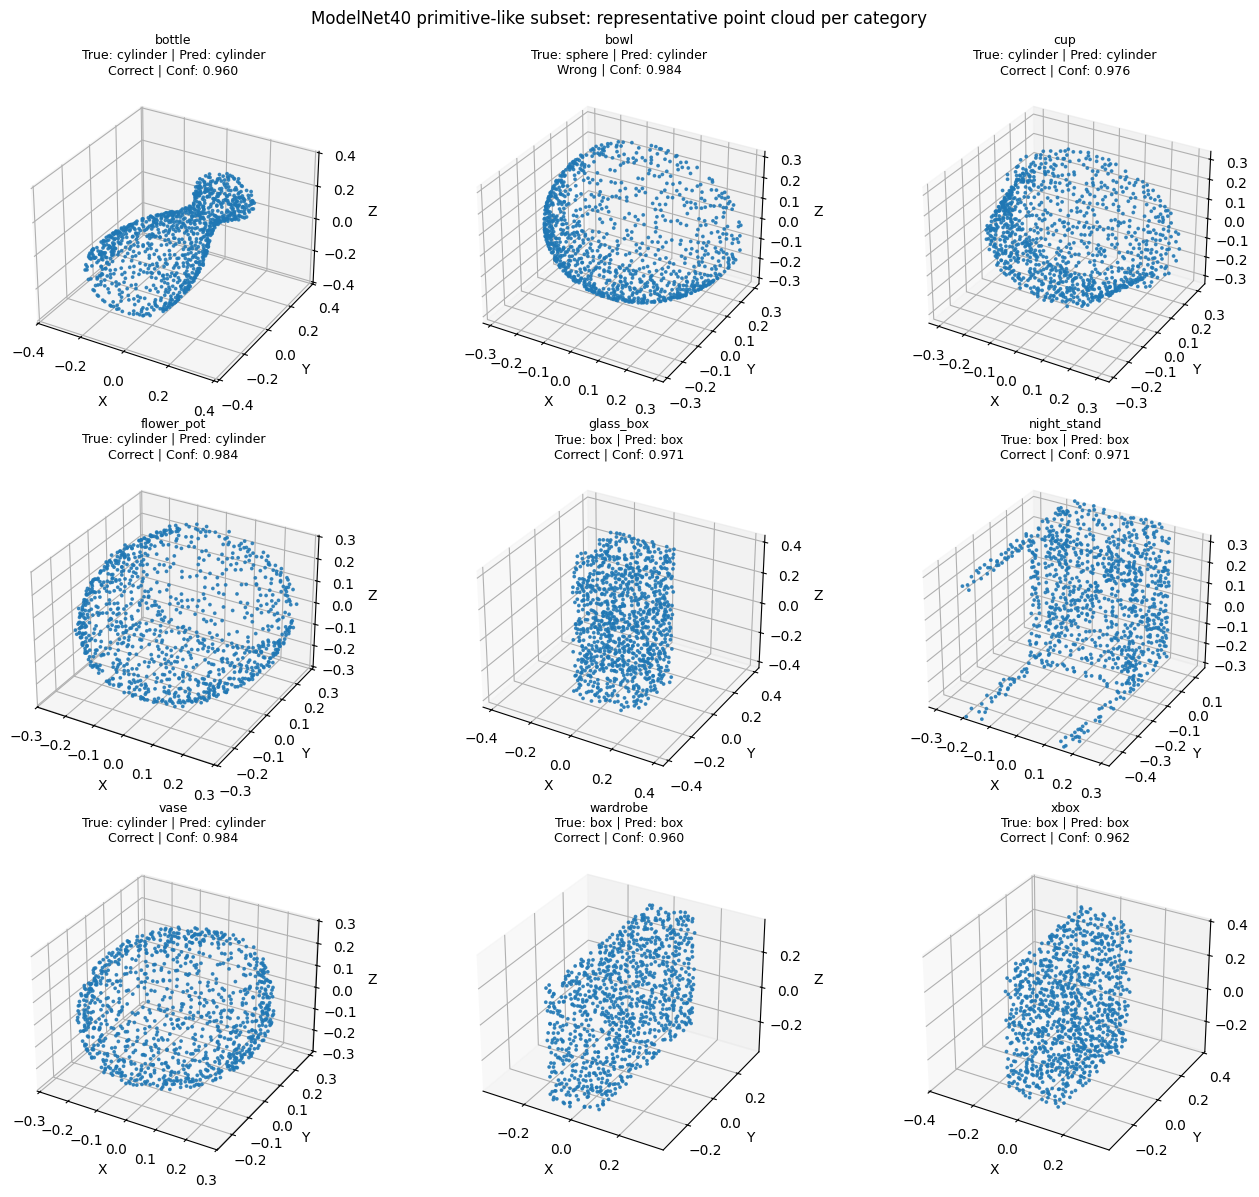

Saved: /content/gdrive/MyDrive/PointNet_APS_Project_V2/figures_final_analysis/modelnet40_subset_voting/modelnet40_voting_representative_category_pointclouds.png


In [ ]:
# Cell 24 - Representative Object Point Clouds
representative_rows = []

for category, group in best_pred_vis.groupby("modelnet_class"):
    group = group.copy()

    correct_group = group[group["correct"] == True]
    wrong_group = group[group["correct"] == False]

    if len(correct_group) > 0:
        chosen = correct_group.sort_values("confidence", ascending=False).iloc[0]
    else:
        chosen = wrong_group.sort_values("confidence", ascending=False).iloc[0]

    representative_rows.append(chosen)

category_examples_df = (
    pd.DataFrame(representative_rows)
    .sort_values("modelnet_class")
    .reset_index(drop=True)
)

display(category_examples_df[[
    "modelnet_class",
    "true_primitive",
    "pred_primitive",
    "correct",
    "confidence",
    "subset_index"
]])

n = len(category_examples_df)
cols = 3
rows = int(np.ceil(n / cols))

fig = plt.figure(figsize=(14, 4 * rows))

for i, (_, row) in enumerate(category_examples_df.iterrows(), start=1):
    ax = fig.add_subplot(rows, cols, i, projection="3d")

    idx = int(row["subset_index"])
    xyz = points_for_vis[idx]

    status = "Correct" if row["correct"] else "Wrong"

    title = (
        f"{row['modelnet_class']}\n"
        f"True: {row['true_primitive']} | Pred: {row['pred_primitive']}\n"
        f"{status} | Conf: {row['confidence']:.3f}"
    )

    plot_point_cloud_array(ax, xyz, title)

plt.suptitle("ModelNet40 primitive-like subset: representative point cloud per category")
plt.tight_layout()

rep_fig = FIG_DIR / "modelnet40_voting_representative_category_pointclouds.png"
plt.savefig(rep_fig, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", rep_fig)

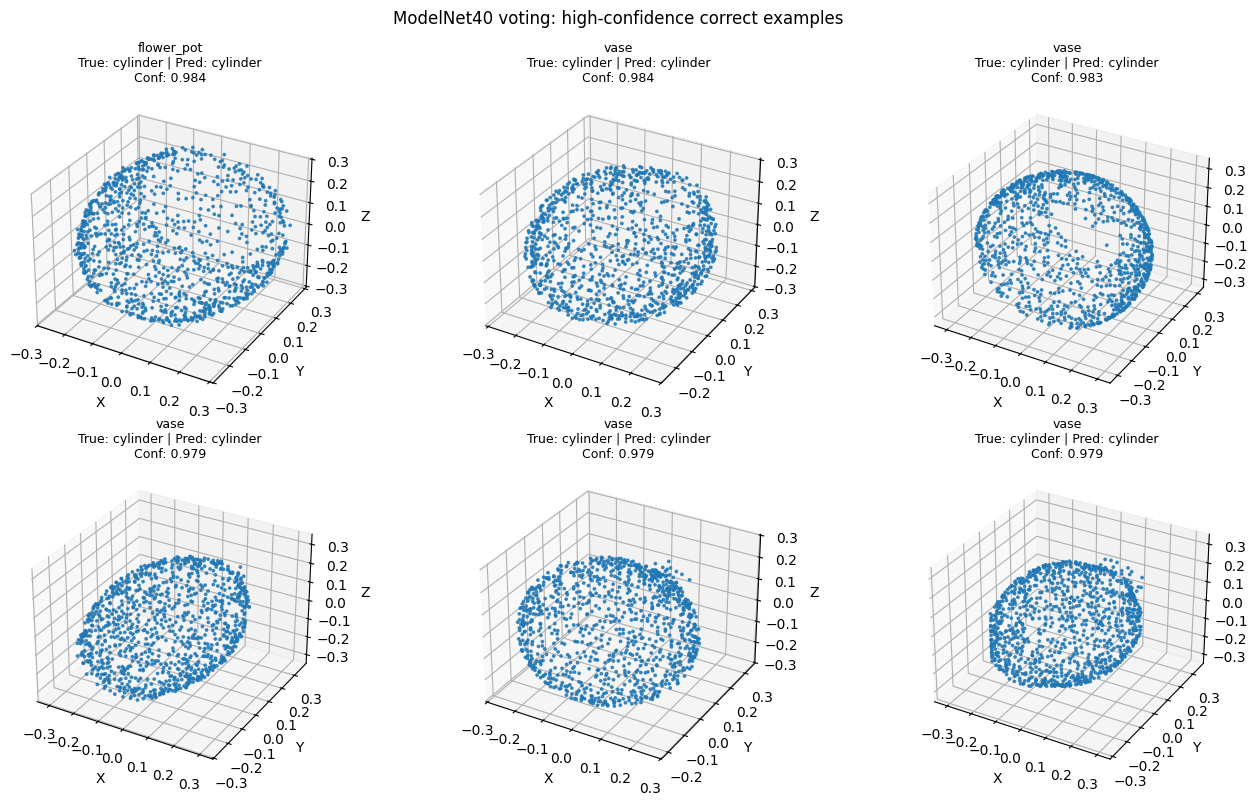

Saved: /content/gdrive/MyDrive/PointNet_APS_Project_V2/figures_final_analysis/modelnet40_subset_voting/modelnet40_voting_correct_examples.png


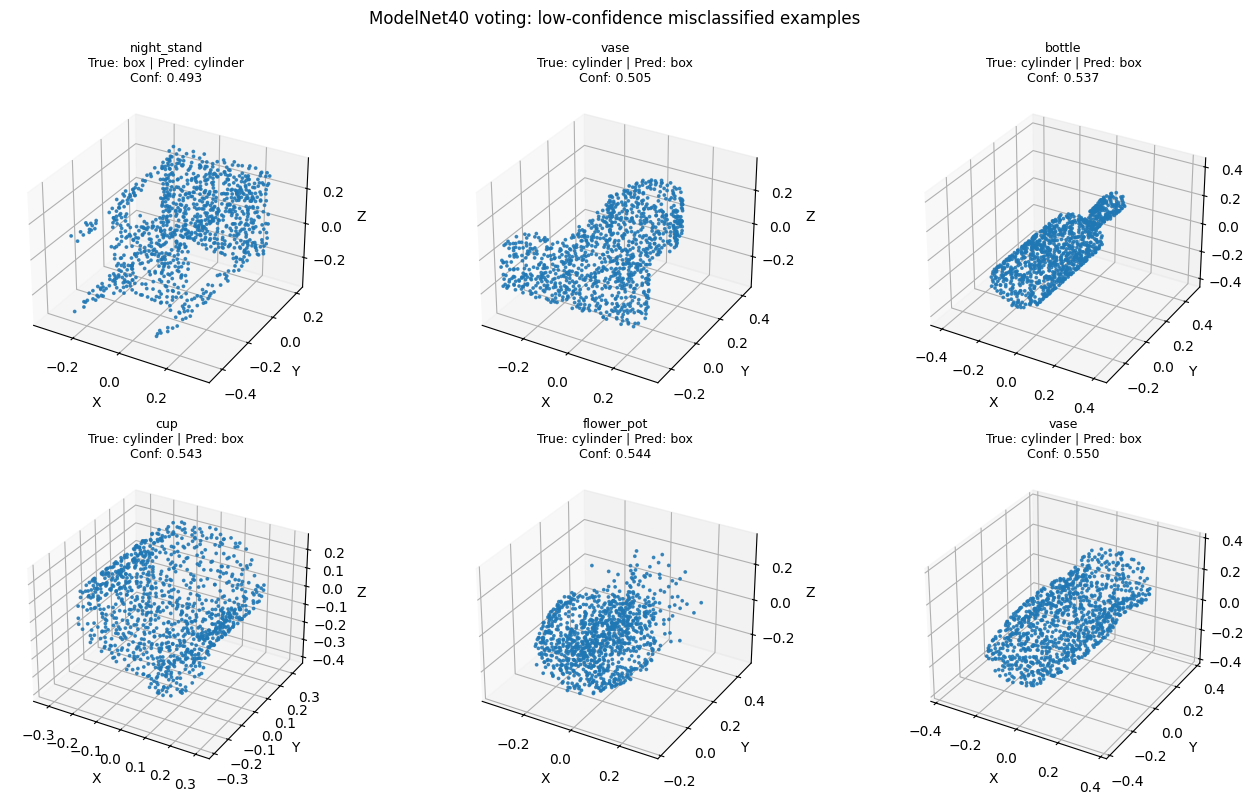

Saved: /content/gdrive/MyDrive/PointNet_APS_Project_V2/figures_final_analysis/modelnet40_subset_voting/modelnet40_voting_wrong_examples.png


In [ ]:
# Cell 25 - Correct and Wrong Prediction Examples
correct_examples = (
    best_pred_vis[best_pred_vis["correct"] == True]
    .sort_values("confidence", ascending=False)
    .head(6)
)

wrong_examples = (
    best_pred_vis[best_pred_vis["correct"] == False]
    .sort_values("confidence", ascending=True)
    .head(6)
)

def visualise_examples(example_df, title, save_name):
    if len(example_df) == 0:
        print("No examples found for:", title)
        return

    cols = 3
    rows = int(np.ceil(len(example_df) / cols))

    fig = plt.figure(figsize=(14, 4 * rows))

    for i, (_, row) in enumerate(example_df.iterrows(), start=1):
        ax = fig.add_subplot(rows, cols, i, projection="3d")

        idx = int(row["subset_index"])
        xyz = points_for_vis[idx]

        plot_title = (
            f"{row['modelnet_class']}\n"
            f"True: {row['true_primitive']} | Pred: {row['pred_primitive']}\n"
            f"Conf: {row['confidence']:.3f}"
        )

        plot_point_cloud_array(ax, xyz, plot_title)

    plt.suptitle(title)
    plt.tight_layout()

    save_path = FIG_DIR / save_name
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", save_path)

visualise_examples(
    correct_examples,
    "ModelNet40 voting: high-confidence correct examples",
    "modelnet40_voting_correct_examples.png"
)

visualise_examples(
    wrong_examples,
    "ModelNet40 voting: low-confidence misclassified examples",
    "modelnet40_voting_wrong_examples.png"
)

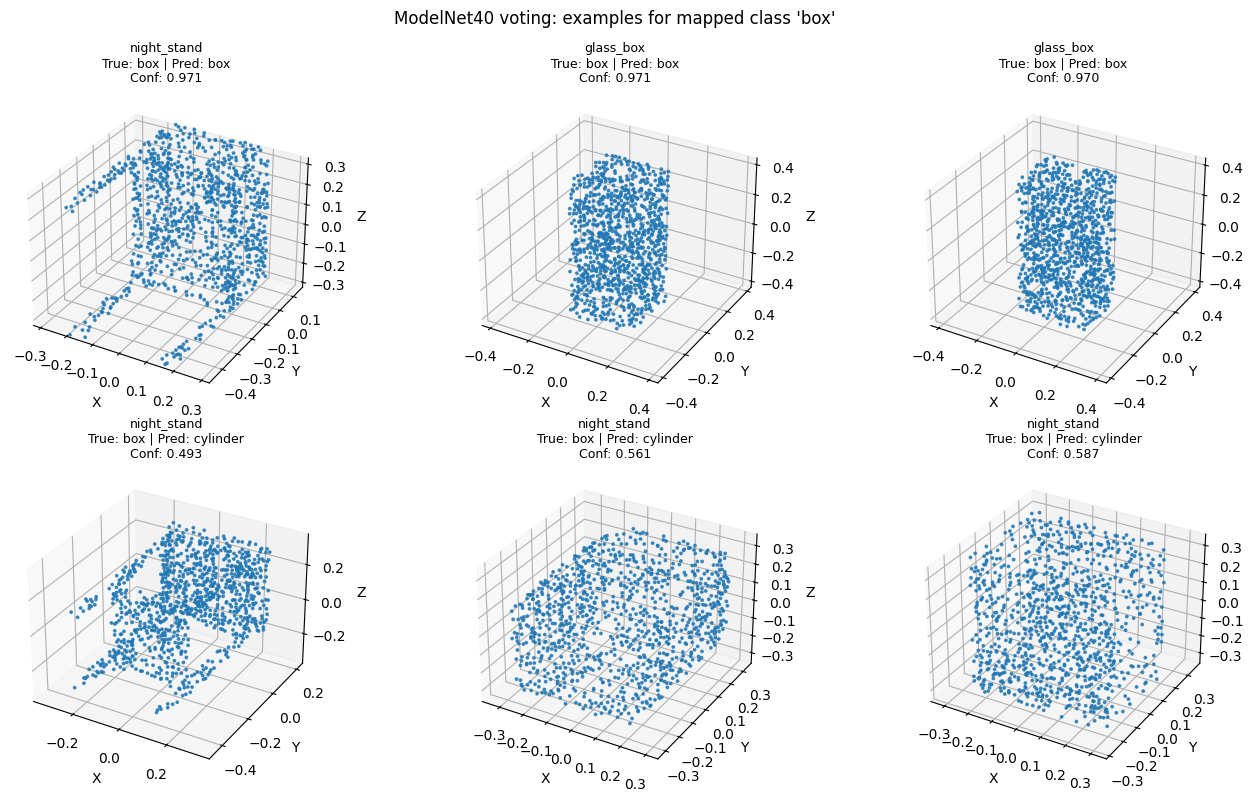

Saved: /content/gdrive/MyDrive/PointNet_APS_Project_V2/figures_final_analysis/modelnet40_subset_voting/modelnet40_voting_box_examples.png


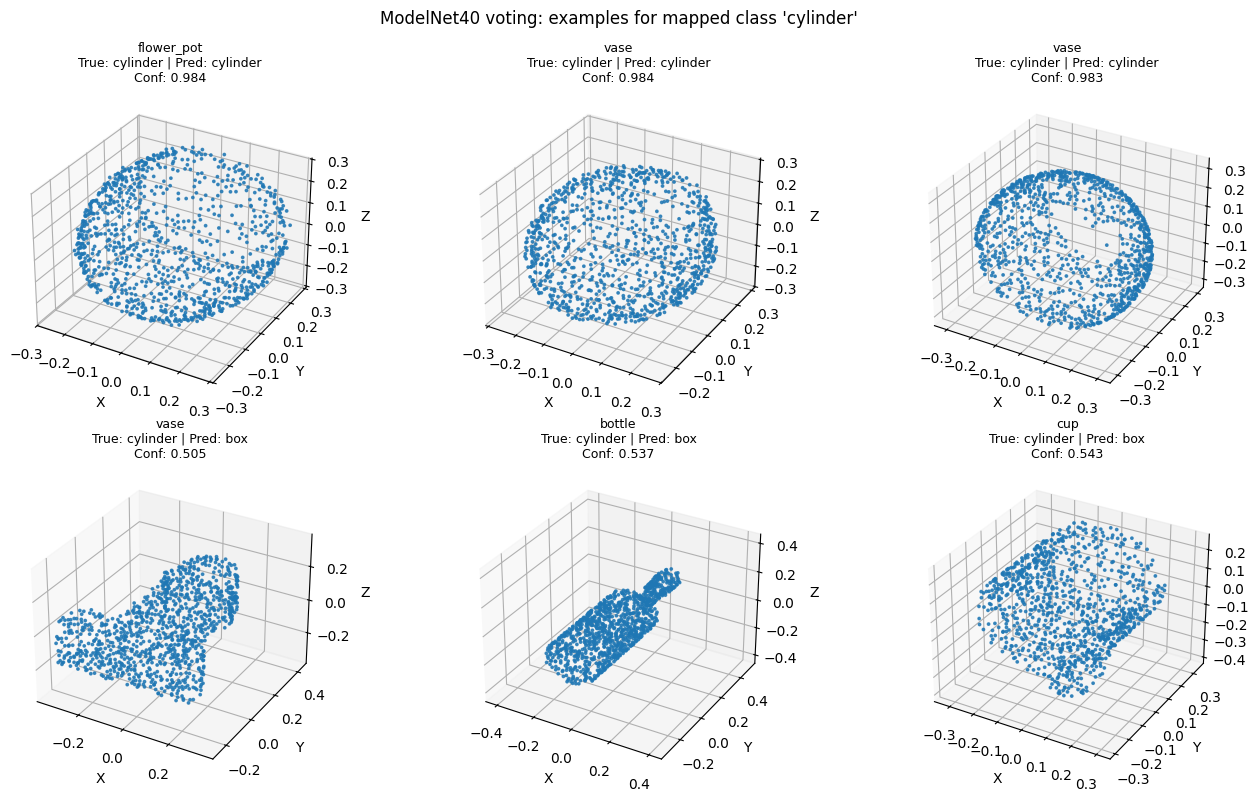

Saved: /content/gdrive/MyDrive/PointNet_APS_Project_V2/figures_final_analysis/modelnet40_subset_voting/modelnet40_voting_cylinder_examples.png


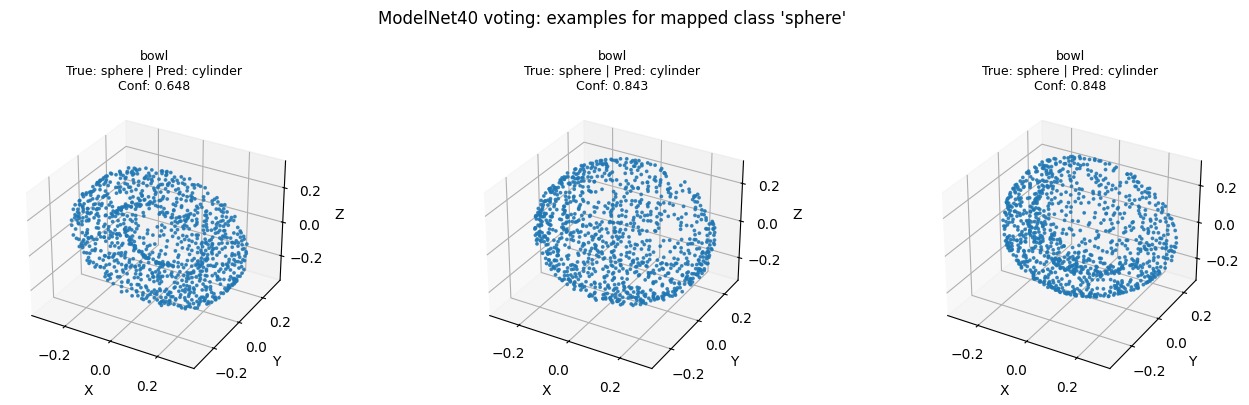

Saved: /content/gdrive/MyDrive/PointNet_APS_Project_V2/figures_final_analysis/modelnet40_subset_voting/modelnet40_voting_sphere_examples.png


In [ ]:
# Cell 26 — Examples by Primitive Class
primitive_examples = []

for primitive, group in best_pred_vis.groupby("true_primitive"):
    group = group.copy()

    correct_group = (
        group[group["correct"] == True]
        .sort_values("confidence", ascending=False)
        .head(3)
    )

    wrong_group = (
        group[group["correct"] == False]
        .sort_values("confidence", ascending=True)
        .head(3)
    )

    selected = pd.concat([correct_group, wrong_group], ignore_index=True).head(6)

    primitive_examples.append((primitive, selected))

for primitive, example_df in primitive_examples:
    visualise_examples(
        example_df,
        f"ModelNet40 voting: examples for mapped class '{primitive}'",
        f"modelnet40_voting_{primitive}_examples.png"
    )

#Final ModelNet40 Interpretation


ModelNet40 was used as an additional external CAD-based test using the standard `modelnet40_ply_hdf5_2048` point-cloud format. Because the trained PointNet++ classifier predicts only box, cylinder and sphere, a primitive-like subset of nine ModelNet40 categories was selected and mapped to the three project classes.

The selected subset contained 486 test samples. Each point cloud was centred, scaled using the bounding-box diagonal and resampled to 1000 XYZ points for evaluation.

Using 10-vote test-time evaluation, the mixed-trained XYZ-only PointNet++ model achieved 81.00% mean accuracy, 82.30% median accuracy and 84.98% best-checkpoint accuracy across nine independently trained checkpoints.

The sphere-like result is limited because ModelNet40 does not contain a true sphere or ball category. The only available sphere-like proxy was `bowl`, which is an open concave object rather than a closed spherical primitive.

________________________________________________

# ***COMPARISON OF CLEAN, ERROR & MIXED - ON MODELNET***
________________________________________________

In [ ]:
# Cell A - Define Single-Pass Evaluation Function

from sklearn.metrics import accuracy_score
from torch.utils.data import DataLoader

dataset = ModelNetPrimitiveDataset(processed_points, subset_df)
loader = DataLoader(dataset, batch_size=16, shuffle=False)

def evaluate_checkpoint_single_pass(ckpt_path, train_condition):
    model = PointNetPPClassifier(num_classes=3, normal_channel=False).to(device)
    model = load_checkpoint(model, ckpt_path)
    model.eval()

    all_true = []
    all_pred = []
    all_conf = []
    prediction_rows = []

    with torch.no_grad():
        for batch in loader:
            x = batch["points"].to(device)
            y = batch["label"].to(device)

            logits = model(x)

            if isinstance(logits, tuple):
                logits = logits[0]

            probs = torch.softmax(logits, dim=1)
            conf, pred = probs.max(dim=1)

            for i in range(len(y)):
                true_idx = int(y[i].cpu())
                pred_idx = int(pred[i].cpu())

                prediction_rows.append({
                    "train_condition": train_condition,
                    "checkpoint": Path(ckpt_path).name,
                    "sample_index": int(batch["sample_index"][i]),
                    "modelnet_class": batch["modelnet_class"][i],
                    "true_primitive": IDX_TO_PRIMITIVE[true_idx],
                    "pred_primitive": IDX_TO_PRIMITIVE[pred_idx],
                    "correct": true_idx == pred_idx,
                    "confidence": float(conf[i].cpu())
                })

                all_true.append(true_idx)
                all_pred.append(pred_idx)
                all_conf.append(float(conf[i].cpu()))

    accuracy = np.mean(np.array(all_true) == np.array(all_pred)) * 100

    summary = {
        "train_condition": train_condition,
        "checkpoint": Path(ckpt_path).name,
        "accuracy_percent": accuracy,
        "n_samples": len(all_true),
        "mean_confidence": np.mean(all_conf)
    }

    return summary, prediction_rows

In [ ]:
# Cell B - Evaluate Clean, Error and Mixed Models

conditions = [
    "clean_trained_xyz",
    "error_trained_xyz",
    "mixed_trained_xyz"
]

all_summary_rows = []
all_prediction_rows = []

for condition in conditions:
    ckpt_dir = PROJECT_DIR / "models_final_xyz" / condition
    checkpoints = sorted(ckpt_dir.glob("*.pth"))

    print("\nCondition:", condition)
    print("Checkpoint folder:", ckpt_dir)
    print("Checkpoints found:", len(checkpoints))

    if len(checkpoints) == 0:
        print("Skipping because no checkpoints found.")
        continue

    for ckpt_path in checkpoints:
        print("Evaluating:", ckpt_path.name)

        summary, preds = evaluate_checkpoint_single_pass(
            ckpt_path,
            condition
        )

        all_summary_rows.append(summary)
        all_prediction_rows.extend(preds)

summary_all_df = pd.DataFrame(all_summary_rows)
pred_all_df = pd.DataFrame(all_prediction_rows)

summary_all_path = RESULTS_DIR / "pointnetpp_xyz_modelnet40_subset_all_conditions_summary_runs.csv"
pred_all_path = RESULTS_DIR / "pointnetpp_xyz_modelnet40_subset_all_conditions_predictions_runs.csv"

summary_all_df.to_csv(summary_all_path, index=False)
pred_all_df.to_csv(pred_all_path, index=False)

print("\nSaved:")
print(summary_all_path)
print(pred_all_path)

display(summary_all_df)


Condition: clean_trained_xyz
Checkpoint folder: /content/gdrive/MyDrive/PointNet_APS_Project_V2/models_final_xyz/clean_trained_xyz
Checkpoints found: 9
Evaluating: clean_trained_xyz_run_1_best.pth
Evaluating: clean_trained_xyz_run_2_best.pth
Evaluating: clean_trained_xyz_run_3_best.pth
Evaluating: clean_trained_xyz_run_4_best.pth
Evaluating: clean_trained_xyz_run_5_best.pth
Evaluating: clean_trained_xyz_run_6_best.pth
Evaluating: clean_trained_xyz_run_7_best.pth
Evaluating: clean_trained_xyz_run_8_best.pth
Evaluating: clean_trained_xyz_run_9_best.pth

Condition: error_trained_xyz
Checkpoint folder: /content/gdrive/MyDrive/PointNet_APS_Project_V2/models_final_xyz/error_trained_xyz
Checkpoints found: 9
Evaluating: error_trained_xyz_run_1_best.pth
Evaluating: error_trained_xyz_run_2_best.pth
Evaluating: error_trained_xyz_run_3_best.pth
Evaluating: error_trained_xyz_run_4_best.pth
Evaluating: error_trained_xyz_run_5_best.pth
Evaluating: error_trained_xyz_run_6_best.pth
Evaluating: error_t

,train_condition,checkpoint,accuracy_percent,n_samples,mean_confidence
0,clean_trained_xyz,clean_trained_xyz_run_1_best.pth,76.131687,486,0.942189
1,clean_trained_xyz,clean_trained_xyz_run_2_best.pth,72.839506,486,0.890982
2,clean_trained_xyz,clean_trained_xyz_run_3_best.pth,69.341564,486,0.892681
3,clean_trained_xyz,clean_trained_xyz_run_4_best.pth,66.255144,486,0.918100
4,clean_trained_xyz,clean_trained_xyz_run_5_best.pth,60.699588,486,0.879364
5,clean_trained_xyz,clean_trained_xyz_run_6_best.pth,76.748971,486,0.935771
6,clean_trained_xyz,clean_trained_xyz_run_7_best.pth,75.308642,486,0.920856
7,clean_trained_xyz,clean_trained_xyz_run_8_best.pth,76.337449,486,0.936267
8,clean_trained_xyz,clean_trained_xyz_run_9_best.pth,71.399177,486,0.916551
9,error_trained_xyz,error_trained_xyz_run_1_best.pth,79.629630,486,0.845577


In [ ]:
# Cell C - Compare Clean, Error and Mixed Results

condition_summary = (
    summary_all_df
    .groupby("train_condition")
    .agg(
        n_runs=("accuracy_percent", "count"),
        mean_accuracy_percent=("accuracy_percent", "mean"),
        std_accuracy_percent=("accuracy_percent", "std"),
        min_accuracy_percent=("accuracy_percent", "min"),
        q1_accuracy_percent=("accuracy_percent", lambda x: np.percentile(x, 25)),
        median_accuracy_percent=("accuracy_percent", "median"),
        q3_accuracy_percent=("accuracy_percent", lambda x: np.percentile(x, 75)),
        max_accuracy_percent=("accuracy_percent", "max"),
        mean_confidence=("mean_confidence", "mean")
    )
    .reset_index()
    .sort_values("mean_accuracy_percent", ascending=False)
)

display(condition_summary)

condition_summary_path = TABLE_DIR / "modelnet40_clean_error_mixed_comparison_summary.csv"
condition_summary.to_csv(condition_summary_path, index=False)

print("Saved:", condition_summary_path)

,train_condition,n_runs,mean_accuracy_percent,std_accuracy_percent,min_accuracy_percent,q1_accuracy_percent,median_accuracy_percent,q3_accuracy_percent,max_accuracy_percent,mean_confidence
2,mixed_trained_xyz,9,80.086877,4.033103,70.164609,80.041152,81.275720,82.098765,83.744856,0.897254
1,error_trained_xyz,9,72.679470,7.618573,62.551440,63.991770,75.102881,77.777778,82.510288,0.878022
0,clean_trained_xyz,9,71.673525,5.445877,60.699588,69.341564,72.839506,76.131687,76.748971,0.914751


Saved: /content/gdrive/MyDrive/PointNet_APS_Project_V2/final_analysis_tables/modelnet40_subset_voting/modelnet40_clean_error_mixed_comparison_summary.csv


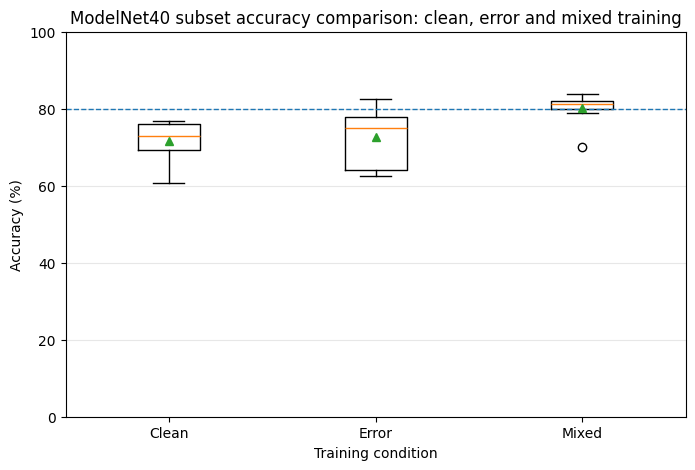

Saved: /content/gdrive/MyDrive/PointNet_APS_Project_V2/figures_final_analysis/modelnet40_subset_voting/modelnet40_clean_error_mixed_accuracy_boxplot.png


In [ ]:
# Cell D - Plot Clean, Error and Mixed Accuracy Comparison

plot_order = [
    "clean_trained_xyz",
    "error_trained_xyz",
    "mixed_trained_xyz"
]

plot_labels = [
    "Clean",
    "Error",
    "Mixed"
]

plot_data = [
    summary_all_df[summary_all_df["train_condition"] == cond]["accuracy_percent"].values
    for cond in plot_order
]

plt.figure(figsize=(8, 5))

plt.boxplot(
    plot_data,
    tick_labels=plot_labels,
    showmeans=True
)

plt.axhline(80, linestyle="--", linewidth=1)

plt.ylabel("Accuracy (%)")
plt.xlabel("Training condition")
plt.title("ModelNet40 subset accuracy comparison: clean, error and mixed training")
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)

boxplot_path = FIG_DIR / "modelnet40_clean_error_mixed_accuracy_boxplot.png"
plt.savefig(boxplot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", boxplot_path)

In [ ]:
# Cell E - Mann-Whitney U Statistical Comparison

from scipy.stats import mannwhitneyu, kruskal
from statsmodels.stats.multitest import multipletests

def cliffs_delta(a, b):
    greater = sum(x > y for x in a for y in b)
    less = sum(x < y for x in a for y in b)
    return (greater - less) / (len(a) * len(b))

acc_by_condition = {
    cond: summary_all_df[summary_all_df["train_condition"] == cond]["accuracy_percent"].dropna().values
    for cond in plot_order
}

# Overall non-parametric test across three conditions
h_stat, kw_p = kruskal(
    acc_by_condition["clean_trained_xyz"],
    acc_by_condition["error_trained_xyz"],
    acc_by_condition["mixed_trained_xyz"]
)

print("Kruskal-Wallis overall test")
print("H statistic:", h_stat)
print("p-value:", kw_p)

pairwise_tests = [
    ("clean_trained_xyz", "error_trained_xyz"),
    ("clean_trained_xyz", "mixed_trained_xyz"),
    ("error_trained_xyz", "mixed_trained_xyz")
]

rows = []
raw_p_values = []

for cond_a, cond_b in pairwise_tests:
    a = acc_by_condition[cond_a]
    b = acc_by_condition[cond_b]

    u_stat, p_value = mannwhitneyu(
        a,
        b,
        alternative="two-sided",
        method="auto"
    )

    raw_p_values.append(p_value)

    rows.append({
        "comparison": f"{cond_a} vs {cond_b}",
        "condition_a": cond_a,
        "condition_b": cond_b,
        "mean_a_percent": np.mean(a),
        "mean_b_percent": np.mean(b),
        "median_a_percent": np.median(a),
        "median_b_percent": np.median(b),
        "mann_whitney_u": u_stat,
        "raw_p_value": p_value,
        "cliffs_delta": cliffs_delta(a, b)
    })

reject, holm_p_values, _, _ = multipletests(
    raw_p_values,
    alpha=0.05,
    method="holm"
)

for i in range(len(rows)):
    rows[i]["holm_corrected_p_value"] = holm_p_values[i]
    rows[i]["significant_after_holm"] = bool(reject[i])

mannwhitney_df = pd.DataFrame(rows)

display(mannwhitney_df)

mannwhitney_path = TABLE_DIR / "modelnet40_mann_whitney_clean_error_mixed.csv"
mannwhitney_df.to_csv(mannwhitney_path, index=False)

overall_stats = pd.DataFrame([{
    "test": "Kruskal-Wallis",
    "h_statistic": h_stat,
    "p_value": kw_p,
    "interpretation": "Overall comparison across clean, error and mixed training conditions"
}])

overall_stats_path = TABLE_DIR / "modelnet40_kruskal_wallis_clean_error_mixed.csv"
overall_stats.to_csv(overall_stats_path, index=False)

print("Saved:", mannwhitney_path)
print("Saved:", overall_stats_path)

Kruskal-Wallis overall test
H statistic: 10.599355385920274
p-value: 0.004993202992062354


,comparison,condition_a,condition_b,mean_a_percent,mean_b_percent,median_a_percent,median_b_percent,mann_whitney_u,raw_p_value,cliffs_delta,holm_corrected_p_value,significant_after_holm
0,clean_trained_xyz vs error_trained_xyz,clean_trained_xyz,error_trained_xyz,71.673525,72.679470,72.839506,75.102881,33.0,0.536499,-0.185185,0.536499,False
1,clean_trained_xyz vs mixed_trained_xyz,clean_trained_xyz,mixed_trained_xyz,71.673525,80.086877,72.839506,81.275720,6.0,0.002666,-0.851852,0.007998,True
2,error_trained_xyz vs mixed_trained_xyz,error_trained_xyz,mixed_trained_xyz,72.679470,80.086877,75.102881,81.275720,13.0,0.017061,-0.679012,0.034122,True


Saved: /content/gdrive/MyDrive/PointNet_APS_Project_V2/final_analysis_tables/modelnet40_subset_voting/modelnet40_mann_whitney_clean_error_mixed.csv
Saved: /content/gdrive/MyDrive/PointNet_APS_Project_V2/final_analysis_tables/modelnet40_subset_voting/modelnet40_kruskal_wallis_clean_error_mixed.csv


In [ ]:
# Cell F - Save Report-Ready Statistical Interpretation

mixed_mean = condition_summary.loc[
    condition_summary["train_condition"] == "mixed_trained_xyz",
    "mean_accuracy_percent"
].iloc[0]

error_mean = condition_summary.loc[
    condition_summary["train_condition"] == "error_trained_xyz",
    "mean_accuracy_percent"
].iloc[0]

clean_mean = condition_summary.loc[
    condition_summary["train_condition"] == "clean_trained_xyz",
    "mean_accuracy_percent"
].iloc[0]

mixed_median = condition_summary.loc[
    condition_summary["train_condition"] == "mixed_trained_xyz",
    "median_accuracy_percent"
].iloc[0]

report_text = f"""
Clean, error and mixed ModelNet40 comparison

The clean-trained, error-trained and mixed-trained XYZ-only PointNet++ models were compared on the same ModelNet40 primitive-like subset using single-pass evaluation. Each condition was evaluated using 9 independently trained checkpoints.

The mixed-trained model achieved the highest mean accuracy at {mixed_mean:.2f}%, followed by the error-trained model at {error_mean:.2f}% and the clean-trained model at {clean_mean:.2f}%. The mixed-trained model also achieved the highest median accuracy at {mixed_median:.2f}%.

A Kruskal-Wallis test showed a significant overall difference between the three training conditions:
H = {h_stat:.4f}, p = {kw_p:.6f}.

Pairwise Mann-Whitney U tests with Holm correction were then used to compare the conditions individually. The clean-trained and error-trained models were not significantly different. However, the mixed-trained model was significantly better than both the clean-trained and error-trained models after Holm correction.

This supports the same conclusion observed in the YCB-28 evaluation: mixed training using both clean and error-style APS data provides the best external generalisation. Therefore, the mixed-trained XYZ-only PointNet++ model was selected for the final 10-vote ModelNet40 evaluation.
"""

print(report_text)

comparison_text_path = TABLE_DIR / "modelnet40_clean_error_mixed_statistical_interpretation.txt"

with open(comparison_text_path, "w") as f:
    f.write(report_text)

print("Saved:", comparison_text_path)


Clean, error and mixed ModelNet40 comparison

The clean-trained, error-trained and mixed-trained XYZ-only PointNet++ models were compared on the same ModelNet40 primitive-like subset using single-pass evaluation. Each condition was evaluated using 9 independently trained checkpoints.

The mixed-trained model achieved the highest mean accuracy at 80.09%, followed by the error-trained model at 72.68% and the clean-trained model at 71.67%. The mixed-trained model also achieved the highest median accuracy at 81.28%.

A Kruskal-Wallis test showed a significant overall difference between the three training conditions:
H = 10.5994, p = 0.004993.

Pairwise Mann-Whitney U tests with Holm correction were then used to compare the conditions individually. The clean-trained and error-trained models were not significantly different. However, the mixed-trained model was significantly better than both the clean-trained and error-trained models after Holm correction.

This supports the same conclusion